# 딥러닝을 이용한 손글씨 분류기

Module import

In [ ]:
from keras.datasets import mnist
from keras.models import Sequential
from keras import layers
from keras.utils import to_categorical
import matplotlib.pyplot as plt
from keras.utils import plot_model

Data preprocessing

In [ ]:
# MNIST 데이터셋 불러오기
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

# 이미지 데이터 준비하기 (모델에 맞는 크기로 바꾸고 0과 1사이로 스케일링)
train_images = train_images.reshape((60000, 28 * 28)) #vector 형태로 변경
train_images = train_images.astype('float32') / 255
test_images = test_images.reshape((10000, 28 * 28))
test_images = test_images.astype('float32') / 255

print(train_labels.shape)
print(test_labels.shape)

# 레이블을 범주형으로 인코딩
train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)

11490434/11490434 [==============================] - 0s 0us/step
(60000,)
(10000,)


Model build

In [ ]:
# 모델 정의하기 (여기에서는 Sequential 클래스 사용)
model = Sequential()
model.add(layers.Dense(100, activation='relu', input_shape=(28 * 28,)))
model.add(layers.Dense(150, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 100)               78500     
                                                                 
 dense_1 (Dense)             (None, 150)               15150     
                                                                 
 dense_2 (Dense)             (None, 10)                1510      
                                                                 
Total params: 95160 (371.72 KB)
Trainable params: 95160 (371.72 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


Compile&training

In [ ]:
# 모델 컴파일 하기
model.compile(optimizer='rmsprop',
                loss='categorical_crossentropy',
                metrics=['accuracy'])

# fit() 함수로 모델 훈련 시키기
hist=model.fit(train_images, train_labels,epochs=3, batch_size=64, verbose=1)

Epoch 1/3
938/938 [==============================] - 8s 8ms/step - loss: 0.2621 - accuracy: 0.9236
Epoch 2/3
938/938 [==============================] - 5s 5ms/step - loss: 0.1136 - accuracy: 0.9655
Epoch 3/3
938/938 [==============================] - 5s 5ms/step - loss: 0.0804 - accuracy: 0.9751


Model Test

In [ ]:
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=0)
print('loss:',test_loss)
print('test_accuracy:',test_acc)

loss: 0.10723251849412918
test_accuracy: 0.9684000015258789


# 딥러닝을 이용한 와인 등급 분류기

데이터 설명

- Alcohol (알코올 함량): 와인의 알콜 함량을 나타내는 특성입니다.
- Malic Acid (말릭 산): 와인에 함유된 말릭 산의 양을 나타내는 특성입니다.
- Ash (회분): 와인의 회분(잔여 물질)을 나타내는 특성입니다.
- Alcalinity of Ash (회분의 알칼리도): 와인의 회분이 얼마나 알칼리성인지를 나타내는 특성입니다.
- Magnesium (마그네슘): 와인에 함유된 마그네슘의 양을 나타내는 특성입니다.
- Total Phenols (총 페놀): 와인에 함유된 총 페놀의 양을 나타내는 특성입니다.
- Flavanoids (플라보노이드): 와인에 함유된 플라보노이드의 양을 나타내는 특성입니다.
- Nonflavanoid Phenols (비 플라보노이드 페놀): 와인에 함유된 비 플라보노이드 페놀의 양을 나타내는 특성입니다.
- Proanthocyanins (프로안소시아닌): 와인에 함유된 프로안소시아닌의 양을 나타내는 특성입니다.
- Color Intensity (색 강도): 와인의 색의 강도를 나타내는 특성입니다.
- Hue (색상): 와인의 색상을 나타내는 특성입니다.
- OD280/OD315 of diluted wines (희석 와인의 OD280/OD315 비율): 희석된 와인의 광학 밀도의 비율을 나타내는 특성입니다.
- Proline (프로린): 와인에 함유된 프로린의 양을 나타내는 특성입니다.

- target (0,1,2): 와인의 클래스를 의미합니다

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential
from keras.layers import Dense
from keras.utils import to_categorical
from keras.callbacks import History

# 데이터 로드
wine_data = load_wine()
X = wine_data.data
y = wine_data.target

# 특성 정규화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 레이블을 one-hot 인코딩
y_one_hot = to_categorical(y)

# 훈련 데이터와 테스트 데이터로 분리
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_one_hot, test_size=0.2, random_state=42)


데이터 시각화

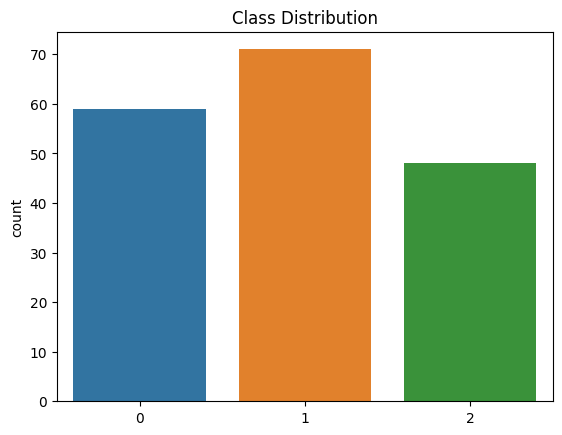

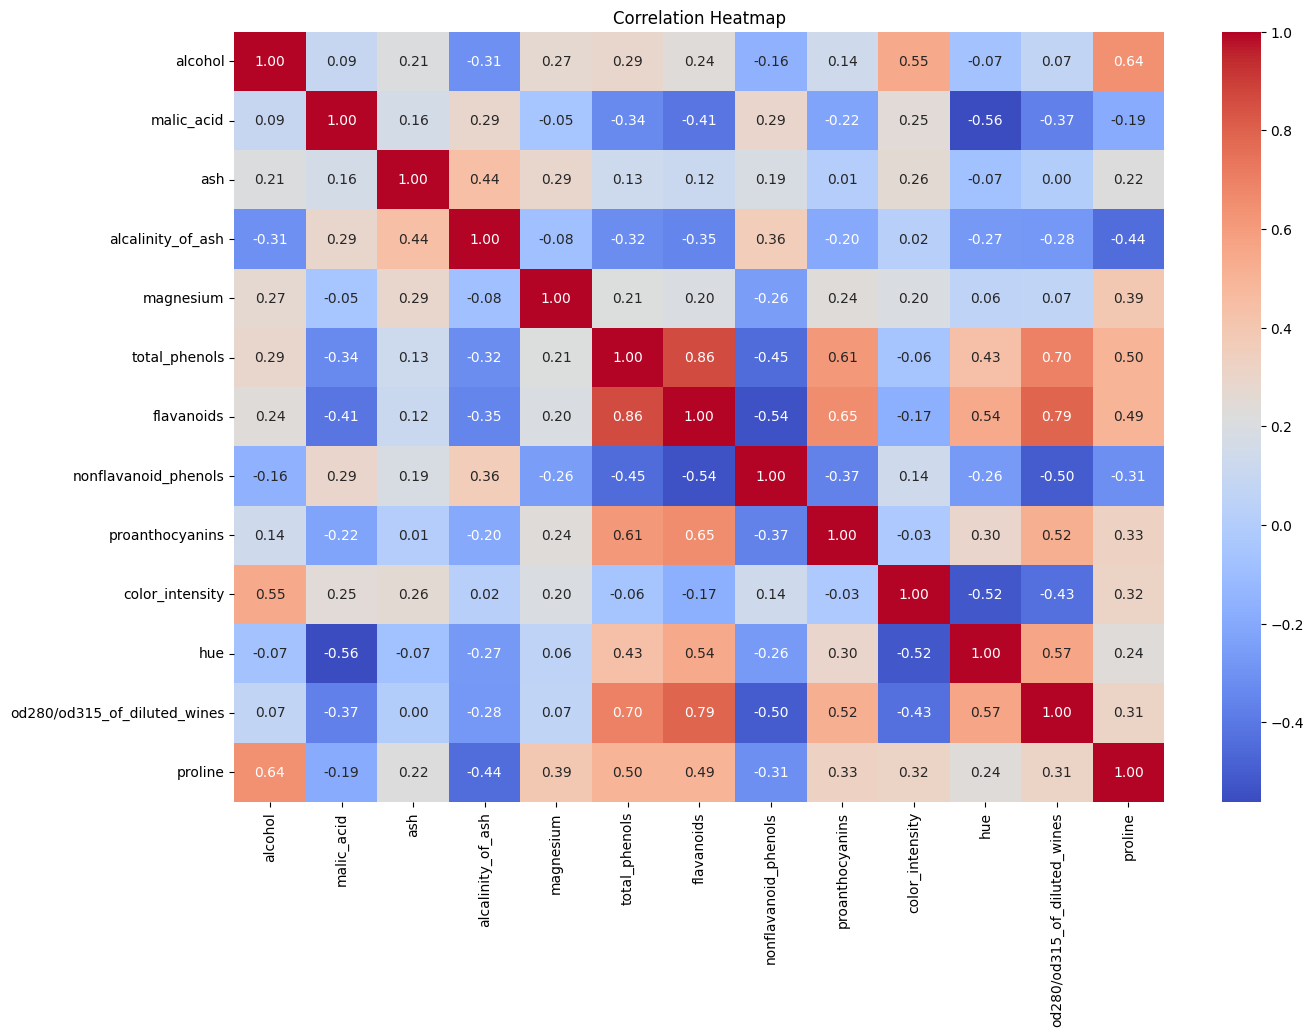

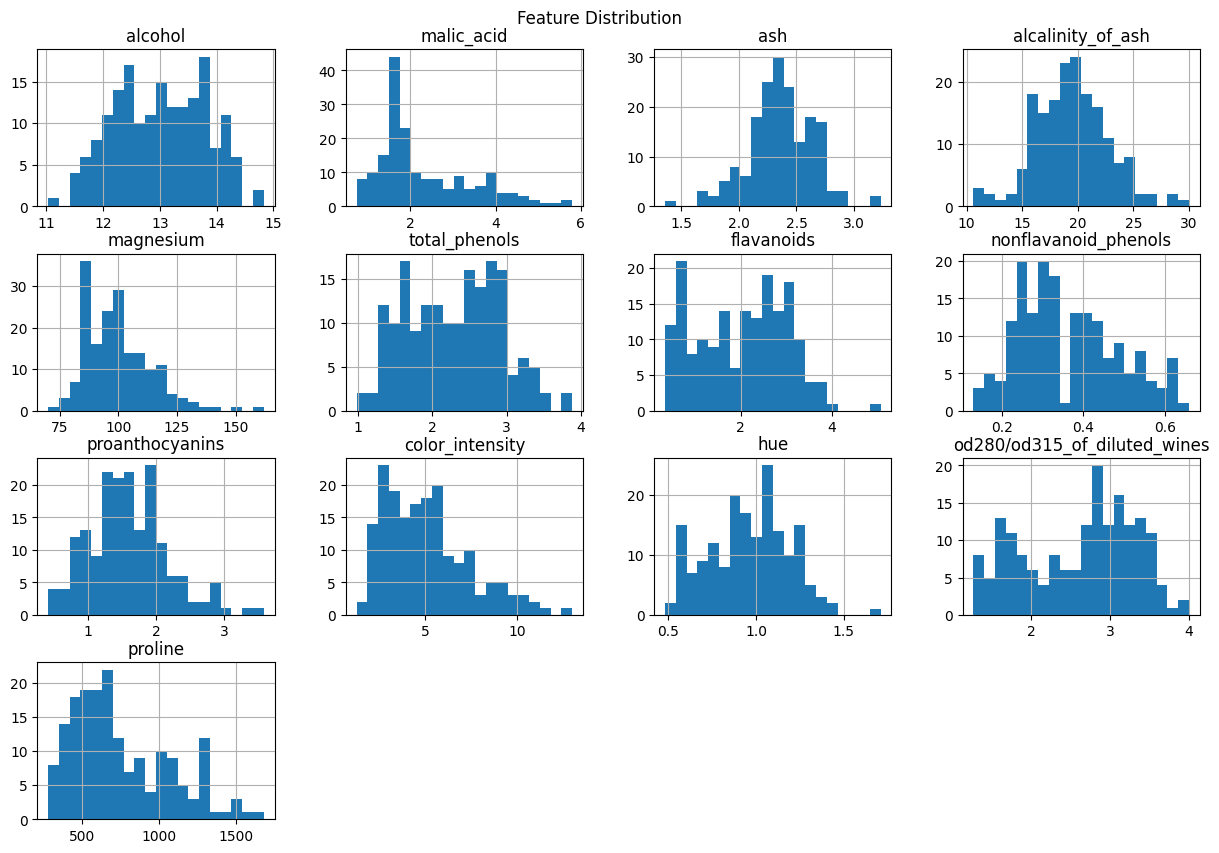

In [ ]:
# 클래스 분포 확인
sns.countplot(x=y)
plt.title('Class Distribution')
plt.show()

# 특성 간 상관관계 시각화
df = pd.DataFrame(X, columns=wine_data.feature_names)
plt.figure(figsize=(15, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

# 특성별 분포 시각화
df.hist(figsize=(15, 10), bins=20)
plt.suptitle('Feature Distribution', x=0.5, y=0.92, ha='center', fontsize='large')
plt.show()

Model build

In [ ]:
# 케라스 모델 생성
model = Sequential()
model.add(Dense(16, input_dim=X_train.shape[1], activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(3, activation='softmax'))  # 클래스의 개수에 맞게 출력 뉴런 수 조정

# 모델 컴파일
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# 모델 학습
history = History()  # 학습 과정을 저장하기 위한 객체
model.fit(X_train, y_train, epochs=50, batch_size=8, validation_data=(X_test, y_test), callbacks=[history])

Epoch 1/50
18/18 [==============================] - 1s 15ms/step - loss: 1.6320 - accuracy: 0.1901 - val_loss: 1.3646 - val_accuracy: 0.2222
Epoch 2/50
18/18 [==============================] - 0s 5ms/step - loss: 1.3368 - accuracy: 0.3310 - val_loss: 1.1217 - val_accuracy: 0.3889
Epoch 3/50
18/18 [==============================] - 0s 5ms/step - loss: 1.1291 - accuracy: 0.4648 - val_loss: 0.9224 - val_accuracy: 0.5556
Epoch 4/50
18/18 [==============================] - 0s 5ms/step - loss: 0.9642 - accuracy: 0.6056 - val_loss: 0.7794 - val_accuracy: 0.7778
Epoch 5/50
18/18 [==============================] - 0s 4ms/step - loss: 0.8390 - accuracy: 0.7042 - val_loss: 0.6664 - val_accuracy: 0.8056
Epoch 6/50
18/18 [==============================] - 0s 5ms/step - loss: 0.7377 - accuracy: 0.7817 - val_loss: 0.5715 - val_accuracy: 0.9722
Epoch 7/50
18/18 [==============================] - 0s 5ms/step - loss: 0.6482 - accuracy: 0.8028 - val_loss: 0.4932 - val_accuracy: 0.9722
Epoch 8/50
18/18 [=

Model Test 및 학습 과정 시각화

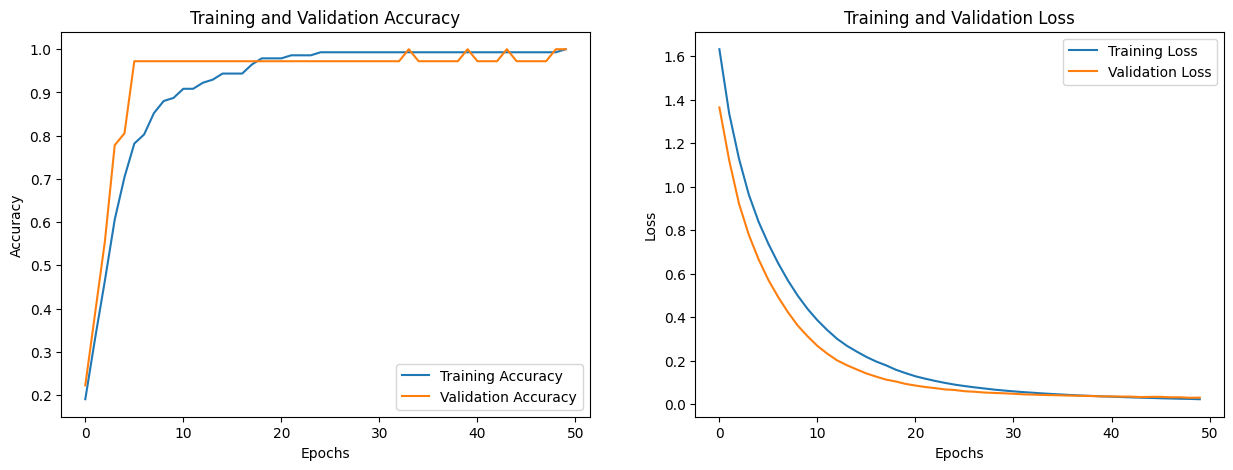

In [ ]:
# 학습 과정 시각화
plt.figure(figsize=(15, 5))

# 정확도 시각화
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# 손실 시각화
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

#딥러닝을 이용한 심장질환 분류기

데이터 설명
- age: 환자의 나이
- sex: 환자의 성별 (1: 남성, 0: 여성)
- cp: 가슴 통증 유형 (chest pain type)
- trestbps: 안정시 혈압 (resting blood pressure)
- chol: 혈청 콜레스테롤 수치 (serum cholesterol)
- fbs: 공복 혈당 수치 (fasting blood sugar)
- restecg: 안정시 심전도 결과 (resting electrocardiographic results)
- thalach: 최대 심박동 수 (maximum heart rate achieved)
- exang: 운동 유발 협심증 여부 (exercise induced angina)
- oldpeak: 운동으로 인한 ST depression
- slope: 운동의 기울기
- ca: 주요 혈관의 수 (number of major vessels colored by fluoroscopy)
- thal: Thalassemia 유형 (thalassemia type)
- target(0,1) : 0=심장질환없음, 1=심장질환있음

Module import & data load

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential
from keras.layers import Dense
from keras.utils import to_categorical

# 데이터 로드
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
names = ["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"]
df = pd.read_csv(url, names=names, na_values="?")


Data preprocessing

In [ ]:
# 결측치 제거
df = df.dropna()

# target 열을 0과 1로 변환
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0) #이부분 전처리 과정 중요!

# 특성과 레이블 분리
X = df.iloc[:, :-1].values
y = df["target"].values

# 훈련 데이터와 테스트 데이터로 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 데이터 정규화
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

데이터 시각화

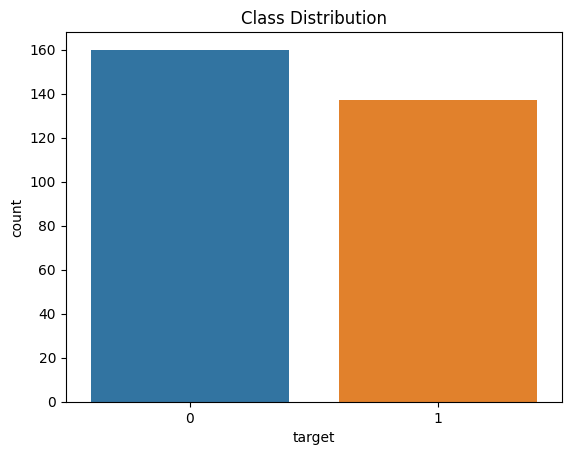

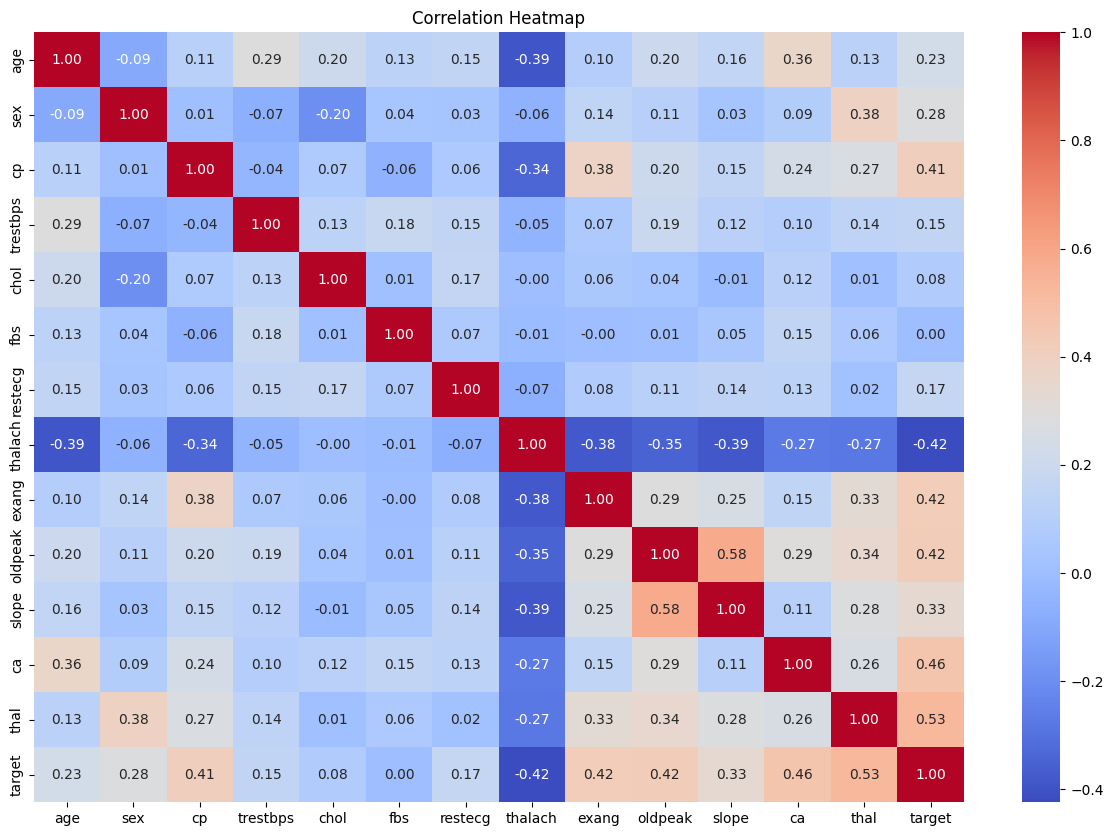

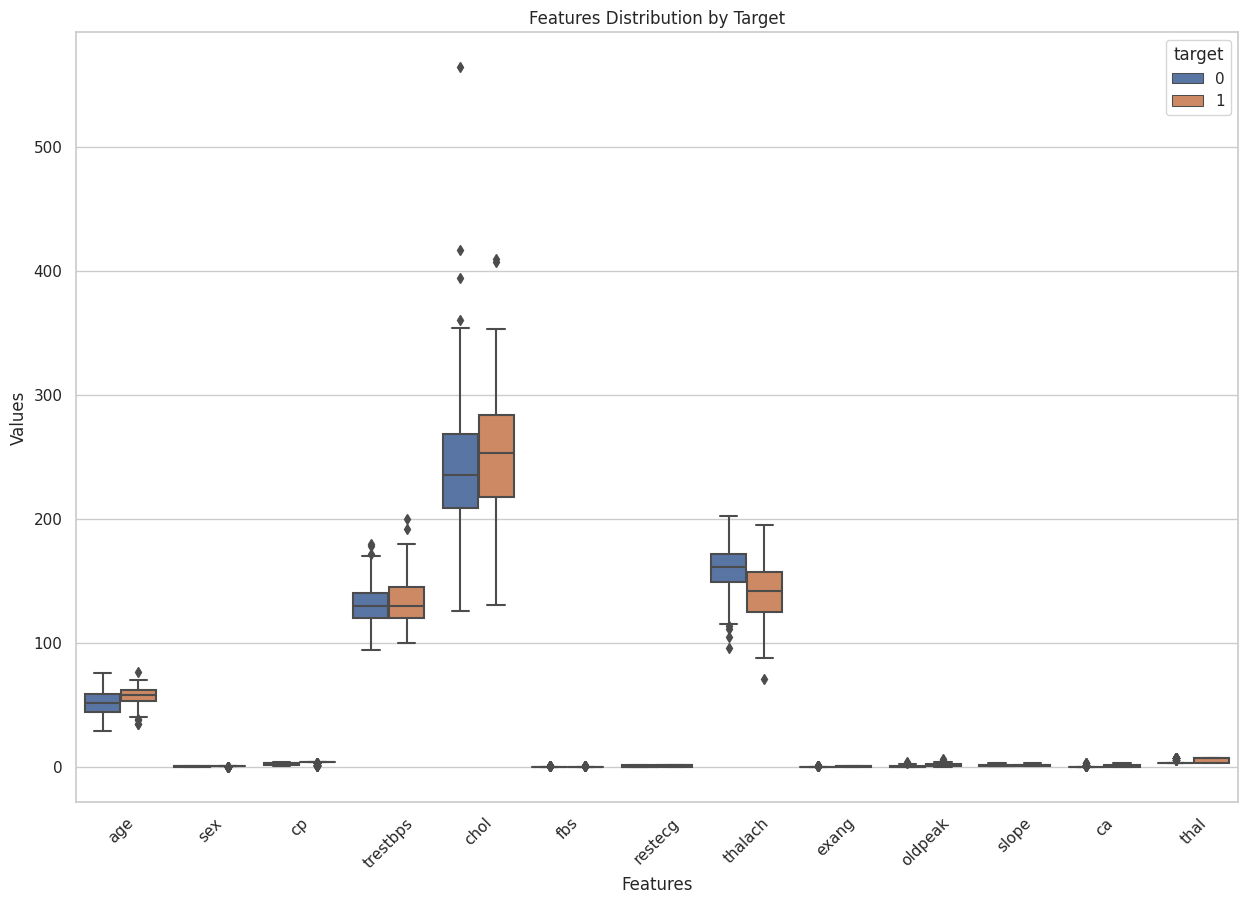

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "<ipython-input-13-2e79738df55e>", line 22, in <cell line: 22>
    sns.pairplot(df, hue="target", palette="husl")
  File "/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py", line 2172, in pairplot
    grid.add_legend()
  File "/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py", line 190, in add_legend
    _draw_figure(self._figure)
  File "/usr/local/lib/python3.10/dist-packages/seaborn/utils.py", line 80, in _draw_figure
    fig.canvas.draw()
  File "/usr/local/lib/python3.10/dist-packages/matplotlib/backends/backend_agg.py", line 400, in draw
    self.figure.draw(self.renderer)
  File "/usr/local/lib/python3.10/dist-packages/matplotlib/artist.py", line 95, in draw_wrapper
    result = draw(artist, renderer, *args, **kwargs)
  File "/usr/local/lib/python3.10/dist-pac

TypeError: ignored

Error in callback <function flush_figures at 0x7d639d6d5240> (for post_execute):


KeyboardInterrupt: ignored

In [ ]:
# 클래스 분포 확인
sns.countplot(x='target', data=df)
plt.title('Class Distribution')
plt.show()

# 특성 간 상관관계 시각화
plt.figure(figsize=(15, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

# 특성별 분포 시각화
sns.set(style="whitegrid")
df_long = pd.melt(df, id_vars="target", var_name="Features", value_name='Values')
plt.figure(figsize=(15, 10))
sns.boxplot(x='Features', y='Values', hue='target', data=df_long)
plt.xticks(rotation=45)
plt.title('Features Distribution by Target')
plt.show()

# Pair Plot
sns.pairplot(df, hue="target", palette="husl")
plt.suptitle('Pair Plot of Features by Target', y=1.02)
plt.show()

Model build

In [ ]:
# 케라스 모델 생성
model = Sequential()
model.add(Dense(16, input_dim=X_train.shape[1], activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# 모델 컴파일
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# 모델 훈련
model.fit(X_train, y_train, epochs=50, batch_size=8, validation_data=(X_test, y_test))


Epoch 1/50
30/30 [==============================] - 1s 9ms/step - loss: 0.8100 - accuracy: 0.5063 - val_loss: 0.7652 - val_accuracy: 0.4833
Epoch 2/50
30/30 [==============================] - 0s 4ms/step - loss: 0.6693 - accuracy: 0.5696 - val_loss: 0.6353 - val_accuracy: 0.5500
Epoch 3/50
30/30 [==============================] - 0s 4ms/step - loss: 0.5991 - accuracy: 0.6414 - val_loss: 0.5371 - val_accuracy: 0.8167
Epoch 4/50
30/30 [==============================] - 0s 6ms/step - loss: 0.5408 - accuracy: 0.7131 - val_loss: 0.4778 - val_accuracy: 0.8500
Epoch 5/50
30/30 [==============================] - 0s 9ms/step - loss: 0.4994 - accuracy: 0.7595 - val_loss: 0.4211 - val_accuracy: 0.8833
Epoch 6/50
30/30 [==============================] - 0s 11ms/step - loss: 0.4622 - accuracy: 0.7848 - val_loss: 0.3852 - val_accuracy: 0.9000
Epoch 7/50
30/30 [==============================] - 0s 9ms/step - loss: 0.4352 - accuracy: 0.8059 - val_loss: 0.3586 - val_accuracy: 0.8833
Epoch 8/50
30/30 [=

Model test

In [ ]:
# 테스트 데이터에서 성능 평가
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test Loss: {loss}, Test Accuracy: {accuracy}')

2/2 [==============================] - 0s 8ms/step - loss: 0.3147 - accuracy: 0.8500
Test Loss: 0.3146853744983673, Test Accuracy: 0.8500000238418579


# 딥러닝을 이용한 당뇨병 예측

문제 정의:
환자의 데이터를 기반으로 당뇨병 발병 여부를 예측.

데이터 정의:
특징변수:
- Pregnancies (임신 횟수): 환자가 현재까지 임신한 횟수
- Glucose (혈당 수치): 2시간 동안의 경구 포도당 내성 검사에서 혈장 포도당 농도
- BloodPressure (혈압): 환자의 혈압 (mm Hg)
- SkinThickness (피부 두께): 삼두근 피부 주름의 두께 (mm)
- Insulin (인슐린): 2시간 동안의 혈청 인슐린 (mu U/ml)
- BMI (체질량 지수): 체중(kg) / 키(m)^2
- DiabetesPedigreeFunction (당뇨가족력 지수): 당뇨병 혈통의 가중치 함수
- Age (나이): 환자의 나이 (세)

타겟 변수(label):
- class: 0,1로 0은 당뇨병이 없음을, 1은 당뇨병이 있음을 나타냅니다.


In [ ]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from keras.models import Sequential
from keras.layers import Dense
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn import preprocessing
import warnings
warnings.filterwarnings("ignore")

input_data=pd.read_csv('diabetes.csv')

input_data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


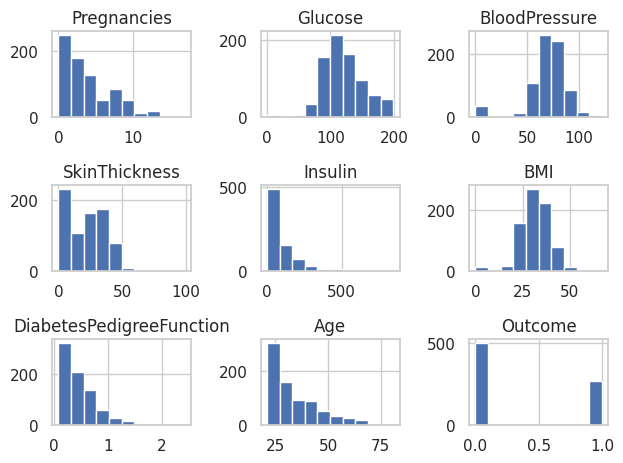

In [ ]:
# 히스토그램을 살펴본다
input_data.hist()
plt.tight_layout()
plt.show()

In [ ]:
def preprocess(df):
    print('----------------------------------------------')
    print("Before preprocessing")
    print("Number of rows with 0 values for each variable")
    for col in df.columns:
        missing_rows = df.loc[df[col]==0].shape[0]
        print(col + ": " + str(missing_rows))
    print('----------------------------------------------')

    # 0이 아닌 값의 평균을 계산해 0 값을 대체
    df['Glucose'] = df['Glucose'].replace(0, np.nan)
    df['BloodPressure'] = df['BloodPressure'].replace(0, np.nan)
    df['SkinThickness'] = df['SkinThickness'].replace(0, np.nan)
    df['Insulin'] = df['Insulin'].replace(0, np.nan)
    df['BMI'] = df['BMI'].replace(0, np.nan)
    df['Glucose'] = df['Glucose'].fillna(df['Glucose'].mean())
    df['BloodPressure'] = df['BloodPressure'].fillna(df['BloodPressure'].mean())
    df['SkinThickness'] = df['SkinThickness'].fillna(df['SkinThickness'].mean())
    df['Insulin'] = df['Insulin'].fillna(df['Insulin'].mean())
    df['BMI'] = df['BMI'].fillna(df['BMI'].mean())

    print('----------------------------------------------')
    print("After preprocessing")
    print("Number of rows with 0 values for each variable")
    for col in df.columns:
        missing_rows = df.loc[df[col]==0].shape[0]
        print(col + ": " + str(missing_rows))
    print('----------------------------------------------')

    # 데이터 표준화
    df_scaled = preprocessing.scale(df)
    df_scaled = pd.DataFrame(df_scaled, columns=df.columns)
    df_scaled['Outcome'] = df['Outcome']
    df = df_scaled
    return df

# 데이터 전처리
preprocessed_df = preprocess(input_data)

----------------------------------------------
Before preprocessing
Number of rows with 0 values for each variable
Pregnancies: 111
Glucose: 5
BloodPressure: 35
SkinThickness: 227
Insulin: 374
BMI: 11
DiabetesPedigreeFunction: 0
Age: 0
Outcome: 500
----------------------------------------------
----------------------------------------------
After preprocessing
Number of rows with 0 values for each variable
Pregnancies: 111
Glucose: 0
BloodPressure: 0
SkinThickness: 0
Insulin: 0
BMI: 0
DiabetesPedigreeFunction: 0
Age: 0
Outcome: 500
----------------------------------------------


train/test split

In [ ]:
# 데이터를 훈련 데이터셋과 테스트 데이터셋으로 분할
X = preprocessed_df.loc[:, preprocessed_df.columns != 'Outcome']
y = preprocessed_df.loc[:, 'Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model build

In [ ]:
# 케라스 신경망을 구축
model = Sequential()
model.add(Dense(32, activation='relu', input_dim=8))
model.add(Dense(16, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

compile 및 학습

In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=100, verbose=1)

Epoch 1/100
20/20 [==============================] - 1s 2ms/step - loss: 0.7137 - accuracy: 0.4625
Epoch 2/100
20/20 [==============================] - 0s 2ms/step - loss: 0.6423 - accuracy: 0.6726
Epoch 3/100
20/20 [==============================] - 0s 2ms/step - loss: 0.5806 - accuracy: 0.7166
Epoch 4/100
20/20 [==============================] - 0s 3ms/step - loss: 0.5293 - accuracy: 0.7329
Epoch 5/100
20/20 [==============================] - 0s 3ms/step - loss: 0.4952 - accuracy: 0.7476
Epoch 6/100
20/20 [==============================] - 0s 3ms/step - loss: 0.4734 - accuracy: 0.7590
Epoch 7/100
20/20 [==============================] - 0s 3ms/step - loss: 0.4600 - accuracy: 0.7704
Epoch 8/100
20/20 [==============================] - 0s 2ms/step - loss: 0.4528 - accuracy: 0.7785
Epoch 9/100
20/20 [==============================] - 0s 2ms/step - loss: 0.4472 - accuracy: 0.7850
Epoch 10/100
20/20 [==============================] - 0s 4ms/step - loss: 0.4414 - accuracy: 0.7850
Epoch 11/

model test

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Accuracy = {:.2f}".format(accuracy))

5/5 [==============================] - 0s 3ms/step - loss: 0.5947 - accuracy: 0.7468
Accuracy = 0.75


confusion matrix

5/5 [==============================] - 0s 7ms/step


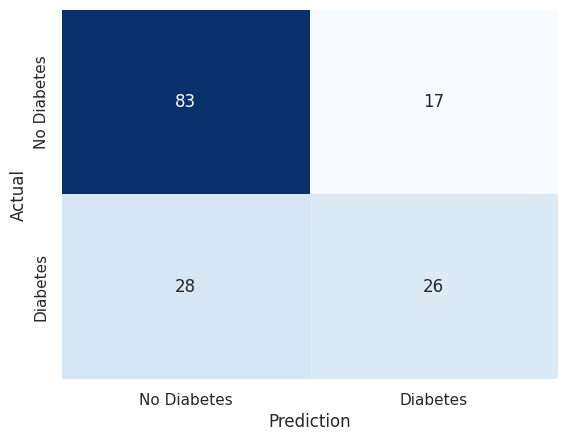

<Figure size 640x480 with 0 Axes>

In [ ]:
# 결과 - 혼동 행렬
y_test_pred = model.predict(X_test)
y_test_pred = np.where(y_test_pred > 0.5, 1 , 0)
c_matrix = confusion_matrix(y_test, y_test_pred)
ax = sns.heatmap(c_matrix, annot=True, xticklabels=['No Diabetes', 'Diabetes'],
                 yticklabels=['No Diabetes', 'Diabetes'], cbar=False, cmap='Blues')
ax.set_xlabel("Prediction")
ax.set_ylabel("Actual")
plt.show()
plt.clf()